In [2]:
# Cell 1 — Load model + data separately
import joblib
import pandas as pd
import numpy as np
import glob
from sklearn.model_selection import train_test_split

# Load model
model = joblib.load("../models/fare_model.pkl")

# Load data (same as model.py)
files = glob.glob("../data/sampled/sample_*.parquet")
dfs = [pd.read_parquet(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

features = [
    "trip_miles", "trip_time", "PULocationID", "DOLocationID",
    "tips", "tolls", "congestion_surcharge", "airport_fee",
    "driver_pay", "trip_minutes", "trip_speed",
    "pickup_hour", "pickup_dayofweek", "is_weekend"
]
target = "base_passenger_fare"

X = df[features]
y = df[target]

# SAME random_state = same split!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preds = model.predict(X_test)

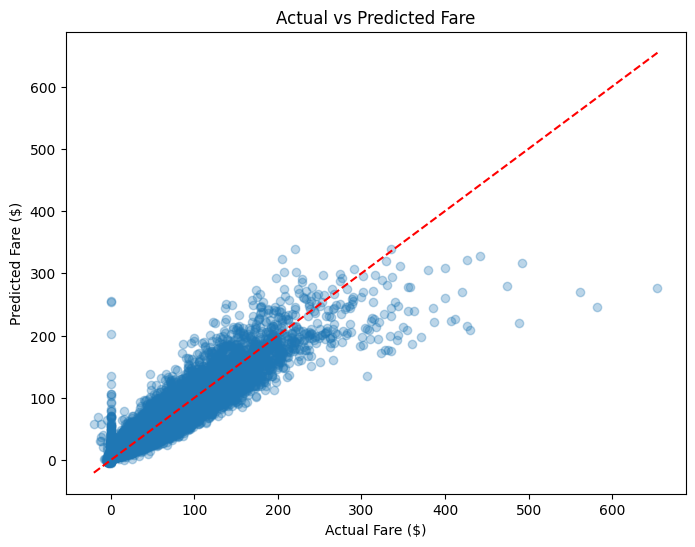

In [4]:
# Cell 2 — Now all plots work
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.xlabel("Actual Fare ($)")
plt.ylabel("Predicted Fare ($)")
plt.title("Actual vs Predicted Fare")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

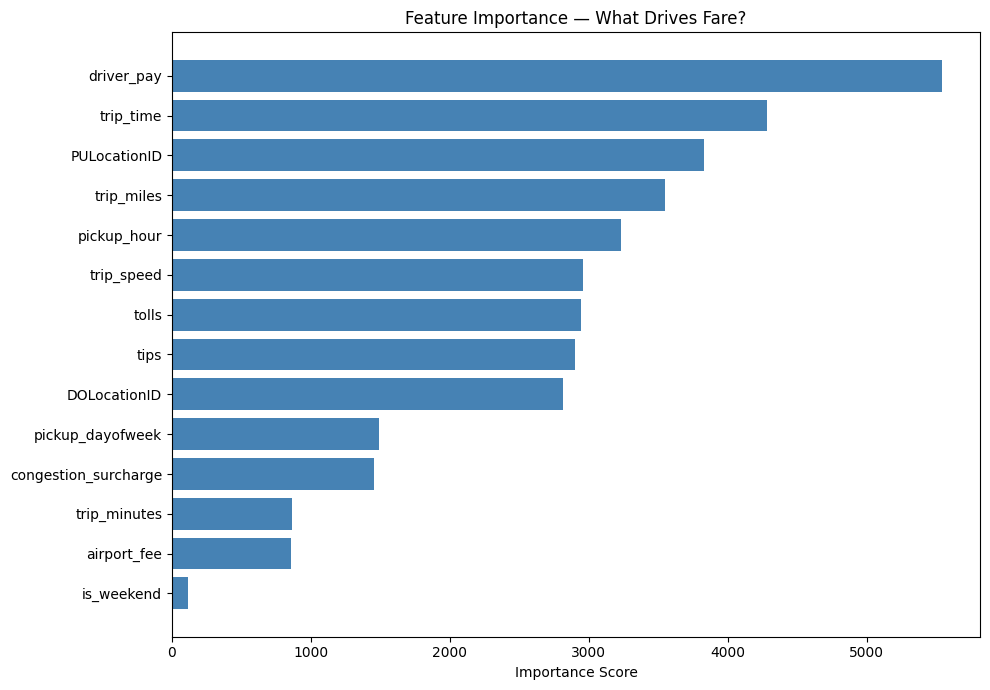

✅ Feature Importance plot saved


In [ ]:
import seaborn as sns
import pandas as pd,matplotlib.pyplot as plt
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — What Drives Fare?') 
plt.tight_layout()
plt.savefig('../visualizations/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature Importance plot saved")

In [ ]:
# Cell 3 — Feature vs Target
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

plot_features = ["trip_miles", "trip_time", "trip_speed", "driver_pay",
                 "tips", "pickup_hour", "congestion_surcharge", "trip_minutes"]

for i, feat in enumerate(plot_features):
    axes[i].scatter(X_test[feat], y_test, alpha=0.2, s=5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("base_passenger_fare")
    axes[i].set_title(f"{feat} vs Fare")

plt.tight_layout()
plt.show()

In [1]:
##tuned hyperparameters comparison
import pandas as pd
df=pd.read_csv("../models/model_comparison.csv")
df.head()

,Model,MAE,RMSE,R2
0,Baseline,4.032883,7.331631,0.905131
1,Tuned,3.979377,7.280977,0.906437


In [3]:
df=pd.read_csv("../models/tuning_results.csv")
df

,Experiment,MAE,RMSE,R2,Trees_Used,Time_Sec,MAE_Change_%
0,9. Best combo v2,3.98,7.28,0.9064,1334,81.3,-1.3
1,8. Best combo v1,3.99,7.29,0.9061,1500,83.2,-1.1
2,"10. Aggressive (slow LR, many trees)",3.99,7.30,0.9060,1997,142.4,-1.1
3,5. Deeper trees,4.00,7.31,0.9058,622,38.8,-0.9
4,6. Higher regularization,4.00,7.29,0.9062,999,49.4,-0.9
5,7. More data sampling,4.01,7.30,0.9059,769,39.9,-0.6
6,2. More trees (1000),4.02,7.32,0.9055,757,32.4,-0.3
7,1. Baseline (original),4.03,7.33,0.9051,498,23.0,0.0
8,4. More trees + Lower LR,4.03,7.33,0.9051,1000,40.4,-0.2
9,3. Lower LR (0.03),4.06,7.37,0.9040,500,25.4,0.7
